In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None  # default='warn'

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import poisson, norm, gamma
#!pip install pymc3
import statsmodels.api as sm
try:
    from pymc3 import *
    import pymc3 as pm
except:
    ! pip install pymc3
    from pymc3 import *
    import pymc3 as pm

import arviz as az

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import Lasso, LassoCV
import plotly.offline as py
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

**Import Dataset**

In [4]:
Tobacco = pd.read_csv("U.S._Chronic_Disease_Indicators__Tobacco.csv", low_memory=False)
Asthma = pd.read_csv("U.S._Chronic_Disease_Indicators__Asthma.csv", low_memory=False)
Tax = pd.read_csv("Excise Tax Rates on Packs of Cigarettes by State (In effect as of September 30, 2022 (n=58)).csv", low_memory=False)
#both PM2.5, Ozone data for JUN 15, 2013 only (to reduce extreme datasize)
PM25 = pd.read_csv("Daily_Census_Tract-Level_PM2.5_Concentrations__2011-2014.csv", low_memory=False)
Ozone = pd.read_csv("Daily_Census_Tract-Level_Ozone_Concentrations__2011-2014.csv", low_memory=False)

**Helper Functions**

In [5]:
#sort by question
def data_by_question(data, question, description):
    data = data[data["Question"] == question]
    data['Abrev'] = description
    return data

#extract relavent data
def extract_data(data):
    return data[['YearStart', 'LocationDesc', 'DataSource', 'DataValueUnit', 'DataValue', 'StratificationCategory1', 'Stratification1', 'Abrev']]

#fix data value to float for quantitative variables
def fix_DataValue_type(data):
    data['DataValue'] = data['DataValue'].astype(float)
    return data

#groupby state 
#categorical will be 2013 value
#quantitative will be the mean value between 
def groupby_state(data, cat = False):
    name = data['Abrev'].iloc[0]
    data = extract_data(data)
    #filter by gender
        
    if cat == False:
        data = data[data["Stratification1"] == "Overall"] #only look at stratification overall value.
        data = fix_DataValue_type(data)
        data = data.groupby('LocationDesc')['DataValue'].mean().reset_index()
        data = data.drop(index = 46).reset_index(drop = True) #drop united states value
    else:
        data = data[data["YearStart"] == 2013]
        data = data.groupby('LocationDesc')['DataValue'].first().reset_index()
    data = data.rename(columns={'DataValue': name})
    return data

#merge data
def merge_df(df1, df2):
    return df1.merge(df2, on ='LocationDesc')

#groupby state with year
def groupby_state2(data, cat = False):
    name = data['Abrev'].iloc[0]
    data = extract_data(data)
    #filter by gender
        
    if cat == False:
        data = data[data["Stratification1"] == "Overall"] #only look at stratification overall value.
        data = fix_DataValue_type(data)
        data = data.groupby(['LocationDesc', 'YearStart'])['DataValue'].mean().reset_index()
        data = data.drop(index = 46).reset_index(drop = True) #drop united states value
    else:
        data = data.groupby(['LocationDesc', 'YearStart'])['DataValue'].first().reset_index()
    data = data.rename(columns={'DataValue': name})
    return data

#merge data with year
def merge_df2(df1, df2):
    return df1.merge(df2, on =['LocationDesc', 'YearStart'])

**Ozone and PM2.5 Data**

In [6]:
#Matching statefips to Location Desc
location = Tobacco[["LocationDesc", "LocationID"]]
location_dropped = location.drop_duplicates(subset = "LocationDesc")
Ozone_grouped = Ozone.groupby("statefips")["ds_o3_pred"].mean().reset_index()
PM25_grouped = PM25.groupby("statefips")["ds_pm_pred"].mean().reset_index()
Ozone_final = Ozone_grouped.merge(location_dropped, how = "left", left_on = "statefips", right_on = "LocationID").drop(columns = ["statefips", "LocationID"])
PM25_final = PM25_grouped.merge(location_dropped, how = "left", left_on = "statefips", right_on = "LocationID").drop(columns = ["statefips", "LocationID"])

**Limit Data from 2013~2020**

In [7]:
Tobacco = Tobacco[Tobacco["YearStart"] > 2012]
Asthma = Asthma[Asthma["YearStart"] > 2012]

**Tobacco Data Cleaning**

In [8]:
Tobacco_strong_polices = data_by_question(Tobacco, 'States with strong polices that require retail licenses to sell tobacco products', 'Strong Retail Policy')
Tobacco_current_smoking = data_by_question(Tobacco,'Current smoking among adults aged >= 18 years', 'Smoking %')
Tobacco_current_smokeless = data_by_question(Tobacco, 'Current smokeless tobacco use among adults aged >= 18 years', 'Smokeless %')
Tobacco_excise_tax = data_by_question(Tobacco, 'Amount of tobacco product excise tax', 'Excise Tax')
Tobacco_sale = data_by_question(Tobacco, 'Sale of cigarette packs', 'Sale per capita')
Tobacco_strong_law = data_by_question(Tobacco, 'States that allow stronger local tobacco control and prevention laws', 'Strong Control & Laws')
Tobacco_youth = data_by_question(Tobacco,'Current cigarette smoking among youth', 'Youth Smoking %')
Tobacco_protection = data_by_question(Tobacco, 'Proportion of the population protected by a comprehensive smoke-free policy prohibiting smoking in all indoor areas of workplaces and public places, including restaurants and bars', 'Protected %')
Tobacco_women_18_44 = data_by_question(Tobacco, 'Current cigarette smoking among women aged 18-44 years', 'Women 18~44 %')

In [9]:
tsp = groupby_state(Tobacco_strong_polices, True) 
tsl = groupby_state(Tobacco_strong_law, True) 
tet = groupby_state(Tobacco_excise_tax, True) 
tcs = groupby_state(Tobacco_current_smoking) 
tsk = groupby_state(Tobacco_current_smokeless) 
tsa = groupby_state(Tobacco_sale) 
tys = groupby_state(Tobacco_youth) 
tpt = groupby_state(Tobacco_protection) 
two = groupby_state(Tobacco_women_18_44) 

**Merged Tobacco Dataset**

In [10]:
dfs = [tet, tcs, tsk, tsa, tys, tpt, two]
Tobacco_Merged = merge_df(tsp, tsl)
for i in range(len(dfs)):
    Tobacco_Merged = merge_df(Tobacco_Merged, dfs[i])
Tobacco_Merged.head()

,LocationDesc,Strong Retail Policy,Strong Control & Laws,Excise Tax,Smoking %,Smokeless %,Sale per capita,Youth Smoking %,Protected %,Women 18~44 %
0,Alabama,Yes,No,No,20.95625,6.10625,58.716667,13.033333,12.700,21.3125
1,Alaska,Yes,No,No,19.36875,6.43125,34.366667,10.250000,45.475,20.1000
2,Arizona,No,No,No,15.08750,2.99375,22.583333,9.150000,77.025,12.3250
3,Arkansas,Yes,No,No,23.61250,6.73750,52.716667,14.550000,0.400,26.2000
4,California,Yes,Yes,No,11.22500,1.69375,20.250000,6.550000,41.925,7.7250


**Asthma Data Cleaning Steps**

In [11]:
Asthma_mortality_rate = data_by_question(Asthma, 'Asthma mortality rate', 'Asthma mortality rate per 100,000')
Asthma_mortality_rate_per = Asthma_mortality_rate[Asthma_mortality_rate["DataValueUnit"].notna()]
Asthma_prevalence = data_by_question(Asthma, 'Current asthma prevalence among adults aged >= 18 years', "Asthma prevalence %")
Asthma_hospitalization = data_by_question(Asthma, 'Hospitalizations for asthma', "Hospitalizations per 10,000")
Asthma_hospitalization_per = Asthma_hospitalization[Asthma_hospitalization["DataValueUnit"].notna()]
Asthma_emergency = data_by_question(Asthma, 'Emergency department visit rate for asthma', "Emergency visit per 10,000")
Asthma_emergency_per = Asthma_emergency[Asthma_emergency["DataValueUnit"].notna()]

In [12]:
amr = groupby_state(Asthma_mortality_rate_per) 
ap = groupby_state(Asthma_prevalence)
ah = groupby_state(Asthma_hospitalization_per)
ae = groupby_state(Asthma_emergency_per)

**Merged Asthma Datasent**

In [13]:
Asthma_merged = merge_df(amr, ap)
Asthma_merged = merge_df(Asthma_merged, ah)
Asthma_merged = merge_df(Asthma_merged, ae)
Asthma_merged.head()

,LocationDesc,"Asthma mortality rate per 100,000",Asthma prevalence %,"Hospitalizations per 10,000","Emergency visit per 10,000"
0,Alabama,17.08750,9.68125,NaN,NaN
1,Alaska,NaN,8.97500,3.410,NaN
2,Arizona,22.17500,9.54375,6.525,45.0125
3,Arkansas,14.03750,9.16250,6.380,41.8850
4,California,56.29375,8.16250,NaN,NaN


**Final Merged Dataset for Casual Inference Modeling**

In [14]:
Final_merged = merge_df(Tobacco_Merged, ap)
Final_merged.head()

,LocationDesc,Strong Retail Policy,Strong Control & Laws,Excise Tax,Smoking %,Smokeless %,Sale per capita,Youth Smoking %,Protected %,Women 18~44 %,Asthma prevalence %
0,Alabama,Yes,No,No,20.95625,6.10625,58.716667,13.033333,12.700,21.3125,9.68125
1,Alaska,Yes,No,No,19.36875,6.43125,34.366667,10.250000,45.475,20.1000,8.97500
2,Arizona,No,No,No,15.08750,2.99375,22.583333,9.150000,77.025,12.3250,9.54375
3,Arkansas,Yes,No,No,23.61250,6.73750,52.716667,14.550000,0.400,26.2000,9.16250
4,California,Yes,Yes,No,11.22500,1.69375,20.250000,6.550000,41.925,7.7250,8.16250


## EDA

<AxesSubplot:>

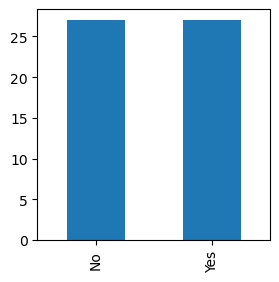

In [15]:
Final_merged["Strong Control & Laws"].value_counts().plot.bar(figsize = (3, 3))

The bar plot shows the number of states that had and didn't have Strong Control & Laws in 2013. From the plot, we can see that we have an even split.

Text(0.5, 0, 'Asthma Prevalence %')

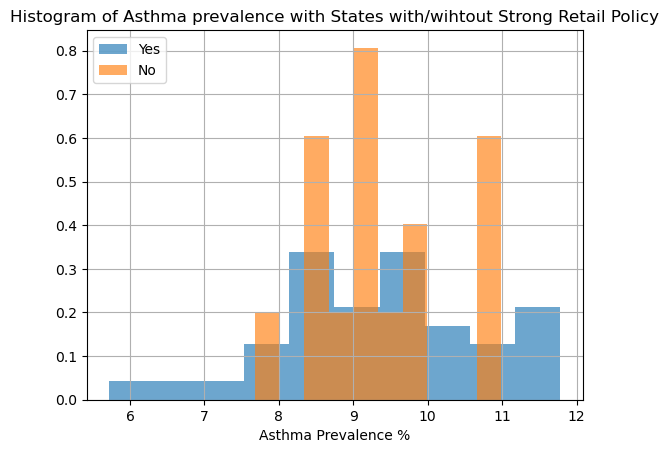

In [16]:
for g in pd.unique(Final_merged["Strong Retail Policy"]):
    Final_merged.loc[Final_merged["Strong Retail Policy"]==g,'Asthma prevalence %'].hist(alpha=0.65,
                                             label=g,density=True)
plt.legend(loc='upper left')
plt.title("Histogram of Asthma prevalence with States with/wihtout Strong Retail Policy")
plt.xlabel("Asthma Prevalence %")

Text(0.5, 0, 'Asthma Prevalence %')

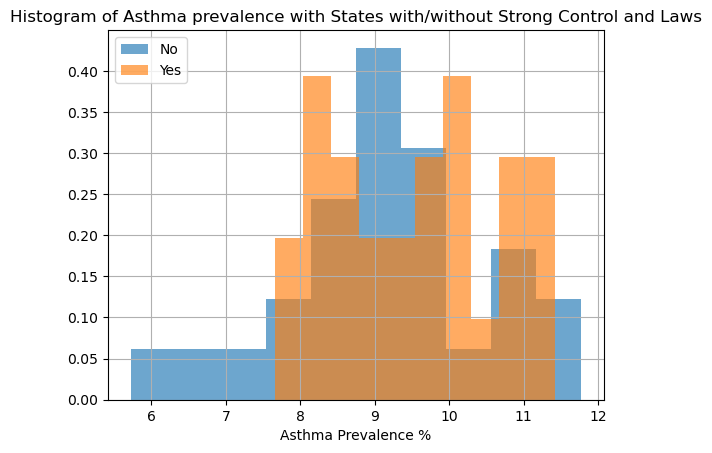

In [17]:
for g in pd.unique(Final_merged["Strong Control & Laws"]):
    Final_merged.loc[Final_merged["Strong Control & Laws"]==g,'Asthma prevalence %'].hist(alpha=0.65,
                                             label=g,density=True)
plt.legend(loc='upper left')
plt.title("Histogram of Asthma prevalence with States with/without Strong Control and Laws")
plt.xlabel("Asthma Prevalence %")

This overlayed histogram shows the prevalence of Asthma for states with Strong control and laws and states without. From the plot, we can see that there isn't a huge difference in the mean value, but we can observe that states with strong longs have a much smaller variation. One of our research questions is determining a casual inference between strong tobacco control laws and asthma rates. From the plot, a potential answer may be that there isn't a casual inference between state laws and asthma prevalence considering the mean values of the histogram doesn't vary much.

array([<AxesSubplot:title={'center':'No'}>,
       <AxesSubplot:title={'center':'Yes'}>], dtype=object)

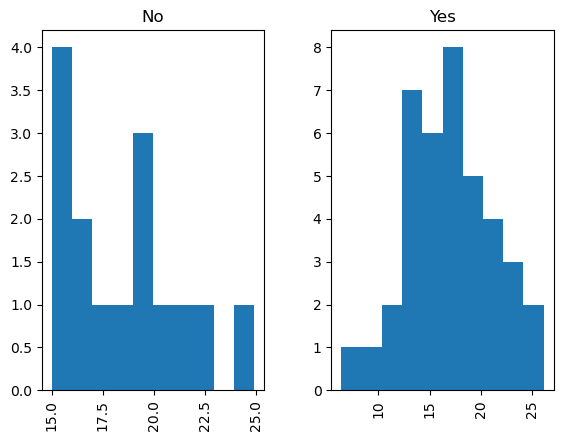

In [18]:
Final_merged.hist(column='Smoking %', by='Strong Retail Policy')

This two plots shows the histogram of smoking % with states with and without strong tobacco retail policy. From the plot, we can see that states with strong retail policies tend to have more states with lower smoking % and a lower mean. This plot is an attempt to find a relation between state policy and the prevalence of smokers in each state if we are to use a Instrumental Variable for our casual inference model. However, further processes should be take to prove a correlation between a categorical variable and a quantitative value such as logarithmic regression.

Text(0.5, 1.0, 'Smoking % vs. Asthma Prevalence')

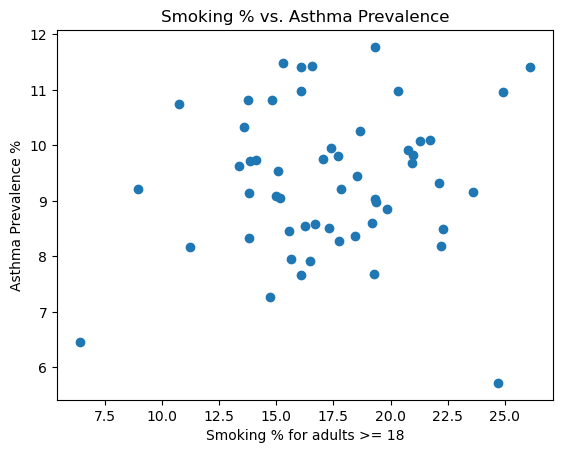

In [19]:
plt.scatter(data = Final_merged, x= "Smoking %", y = "Asthma prevalence %")
plt.xlabel("Smoking % for adults >= 18")
plt.ylabel("Asthma Prevalence %")
plt.title("Smoking % vs. Asthma Prevalence")

This scatter plot shows a relationship between the percentage of smokers and the prevalence of asthma in a certain state. The plot seems to have a slightly positive correlation with higher smoking % linked with higher asthma rates. However, There are a few outliers that may skew this result. One example is Virgin Island which has one of the highest smoking % but with one of the lowest Asthma Prevalence. From these outliers, we raise a question of other factors than Tobacco affecting asthma prevalence. As a result, PM2.5 and Ozone level data will be used in our Prediction Model to answer this question.

Text(0.5, 1.0, 'Youth Smoking % vs. Asthma Prevalence')

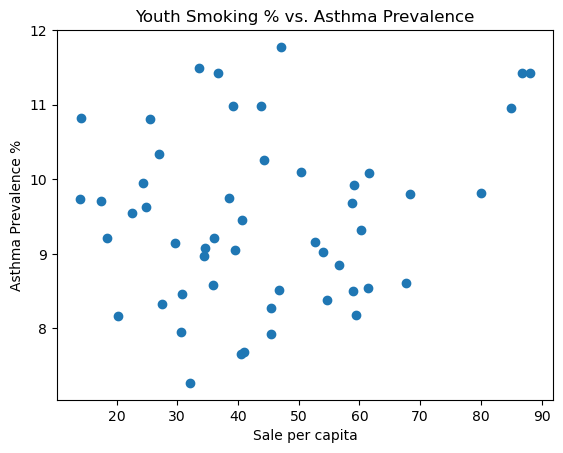

In [20]:
plt.scatter(data = Final_merged, x= "Sale per capita", y = "Asthma prevalence %")
plt.xlabel("Sale per capita")
plt.ylabel("Asthma Prevalence %")
plt.title("Youth Smoking % vs. Asthma Prevalence")

This scatter plot shows a relationship between the number of Tobacco packs sold per capita and the prevalence of asthma in a certain state. The plot seems to have a stronger positive correlation than the plot above between smoking % and asthma rates. This plot may be more important than smoking % in proving casual inference between Tobacco state laws and Asthma Prevalence because a significant number of asthma patients may be due to second hand smoking which may not be accurately represented in the smoking % data. If there is a strong correlation between state laws and the number of packs sold per captia, we could use state laws as an IV to sales per capita to prove casuation between tobacco and Asthma.

## Modeling

## GLM Prediction

**Dataset Creation**

In [21]:
tsp2 = groupby_state2(Tobacco_strong_polices, True) 
tsl2 = groupby_state2(Tobacco_strong_law, True) 
tet2 = groupby_state2(Tobacco_excise_tax, True) 
tcs2 = groupby_state2(Tobacco_current_smoking) 
tsk2 = groupby_state2(Tobacco_current_smokeless) 
tsa2 = groupby_state2(Tobacco_sale) 
two2 = groupby_state2(Tobacco_women_18_44) 
ap2 = groupby_state2(Asthma_prevalence)

In [22]:
dfs2 = [tet2, tcs2, tsk2, tsa2, two2, ap2]
Tobacco_Merged2 = merge_df2(tsp2, tsl2)
for i in range(len(dfs2)):
    Tobacco_Merged2 = merge_df2(Tobacco_Merged2, dfs2[i])

In [23]:
random_forest_df = merge_df(Tobacco_Merged2, Ozone_final)
random_forest_df = merge_df(random_forest_df, PM25_final)
random_forest_df['strong_retail'] = np.where(random_forest_df['Strong Retail Policy'] == "Yes", 1, 0)
random_forest_df['strong_law'] =  np.where(random_forest_df['Strong Control & Laws'] == "Yes", 1, 0)
random_forest_df['tax'] = np.where(random_forest_df['Excise Tax'] == "Yes", 1, 0)
random_forest_df = random_forest_df.dropna()
random_forest_df = random_forest_df.drop(columns=['Strong Retail Policy', 'Strong Control & Laws', 'Excise Tax'])
random_forest_df.head()

,LocationDesc,YearStart,Smoking %,Smokeless %,Sale per capita,Women 18~44 %,Asthma prevalence %,ds_o3_pred,ds_pm_pred,strong_retail,strong_law,tax
0,Alabama,2013,21.80,6.20,64.6,21.7,8.50,52.124863,12.532084,1,0,0
1,Alabama,2014,21.40,5.90,61.7,21.5,9.50,52.124863,12.532084,1,0,0
2,Alabama,2017,21.40,6.40,58.1,21.9,10.90,52.124863,12.532084,1,0,0
3,Alabama,2018,19.60,6.45,54.7,19.2,10.45,52.124863,12.532084,1,0,0
4,Alabama,2019,20.75,6.40,53.1,22.6,9.45,52.124863,12.532084,1,0,0


## Non Parametric Model

Train/Test Split

In [24]:
train, test = train_test_split(random_forest_df, test_size=0.30, random_state=101)

In [25]:
X_cols = ["YearStart", "strong_law", "strong_retail", "tax", "Smoking %", "Smokeless %", "Sale per capita", "ds_o3_pred",  "ds_pm_pred"] # Columns used for prediction
y_col = "Asthma prevalence %" # The column we're trying to predict

**Random Forest Model**

In [26]:
forest_model = RandomForestRegressor(max_features=1)
fm = forest_model.fit(train[X_cols], train[y_col])
fm_train = fm.predict(train[X_cols])
fm_test = fm.predict(test[X_cols])
train["forest_pred"] = fm_train
test["forest_pred"] = fm_test

**Model Evaluation**

In [27]:
train_rmse = np.mean((train["forest_pred"] - train["Asthma prevalence %"]) ** 2) ** 0.5
test_rmse = np.mean((test["forest_pred"] - test["Asthma prevalence %"]) ** 2) ** 0.5

print("Training set error for random forest:", train_rmse)
print("Test set error for random forest:    ", test_rmse)

Training set error for random forest: 0.3671141133072234
Test set error for random forest:     1.0892961705891901


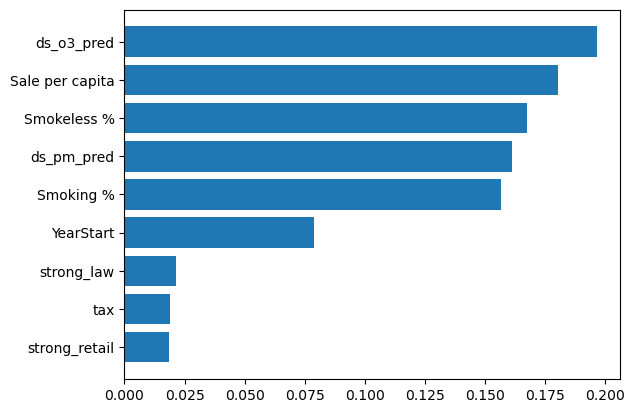

In [28]:
#From StackOverFlow
f_i = list(zip(X_cols,forest_model.feature_importances_))
f_i.sort(key = lambda x : x[1])
plt.barh([x[0] for x in f_i],[x[1] for x in f_i])

plt.show()

In [29]:
from sklearn.feature_selection import RFECV
rfe = RFECV(forest_model, cv=5, scoring="neg_mean_squared_error")

rfe.fit(train[X_cols], train[y_col])

RFECV(cv=5, estimator=RandomForestRegressor(max_features=1),
      scoring='neg_mean_squared_error')

In [30]:
selected_features = np.array(X_cols)[rfe.get_support()]
selected_features

array(['ds_o3_pred'], dtype='<U15')

In [31]:
rfm_train = rfe.predict(train[X_cols])
rfm_test = rfe.predict(test[X_cols])

In [32]:
rtrain_rmse = np.mean((rfm_train - train["Asthma prevalence %"]) ** 2) ** 0.5
rtest_rmse = np.mean((rfm_test - test["Asthma prevalence %"]) ** 2) ** 0.5

print("Training set error for random forest:", rtrain_rmse)
print("Test set error for random forest:    ", rtest_rmse)

Training set error for random forest: 0.5527546749349245
Test set error for random forest:     0.8216700073224807


## GLM

**Choosing Features**

In [33]:
def rmse_score(model, X, y):
    return np.sqrt(np.mean((y - model.predict(X))**2))

def compare_models(models, tr):
    # Compute the training error for each model
    training_rmse = [rmse_score(model, tr, tr['Asthma_prev']) for model in models.values()]
    # Compute the cross validation error for each model
    validation_rmse = [np.mean(cross_val_score(model, tr, tr['Asthma_prev'], scoring=rmse_score, cv=5)) 
                       for model in models.values()]
    names = list(models.keys())
    fig = go.Figure([
        go.Bar(x = names, y = training_rmse, name="Training RMSE"),
        go.Bar(x = names, y = validation_rmse, name="CV RMSE"),
    ])
    fig.update_yaxes(title="RMSE")
    return fig

In [34]:
choose_features_df = random_forest_df.rename(columns={"strong_retail" : "Retail",
                                                  "strong_law" : "Laws",
                                                  "tax" : "Tax",
                                                  "Smoking %" : "Tobacco_prev", 
                                                  "Smokeless %" : "Vape_Prev", 
                                                  "Sale per capita" : "Sale_p_c", 
                                                  "Women 18~44 %" : "Women", 
                                                  "Asthma prevalence %" : "Asthma_prev",
                                                  "ds_o3_pred" : "o3",
                                                  "ds_pm_pred" : "pm"})

In [35]:
models = {}

In [36]:
train, test = train_test_split(choose_features_df, test_size=0.20, random_state=101)

In [37]:
quantitative_features = ["Tobacco_prev", "Vape_Prev", "Sale_p_c", "Women", "o3", "pm"]

In [38]:
for i in range(len(quantitative_features)):
    # The features to include in the ith model
    features = quantitative_features[:(i+1)]
    # The name we are giving to the ith model
    name = ",".join([name[0] for name in features])
    # The pipeline for the ith model
    model = Pipeline([
        ("SelectColumns", ColumnTransformer([
            ("keep", "passthrough", features),
        ])),
        ("Imputation", SimpleImputer()),
        ("LinearModel", LinearRegression())
    ])
    # Fit the pipeline
    model.fit(train, train['Asthma_prev']);
    # Saving the ith model
    models[name] = model
models.keys()

dict_keys(['T', 'T,V', 'T,V,S', 'T,V,S,W', 'T,V,S,W,o', 'T,V,S,W,o,p'])

In [39]:
model_three = Pipeline([
    ("SelectColumns", ColumnTransformer([
        ("keep", "passthrough", quantitative_features),
        ("retail_encoder", OneHotEncoder(handle_unknown='ignore'), ["Retail"]),
        ("law_encoder", OneHotEncoder(handle_unknown='ignore'), ["Laws"]),
        ("tax_encoder", OneHotEncoder(handle_unknown='ignore'), ["Tax"])
    ])),
    ("Imputation", SimpleImputer()),
    ("LinearModel", LinearRegression())
])

In [40]:
model_three.fit(train, train['Asthma_prev'])
name = ",".join([name[0] for name in quantitative_features]) + ",R" + ",L" + ",T"
models[name] = model_three

In [41]:
alphas = np.linspace(0.5, 3, 30)
ridge_model = Pipeline([
    ("SelectColumns", ColumnTransformer([
        ("keep", "passthrough", quantitative_features),
        ("retail_encoder", OneHotEncoder(handle_unknown='ignore'), ["Retail"]),
        ("law_encoder", OneHotEncoder(handle_unknown='ignore'), ["Laws"]),
        ("tax_encoder", OneHotEncoder(handle_unknown='ignore'), ["Tax"])
    ])),
    ("Imputation", SimpleImputer()),
    ("LinearModel", RidgeCV(alphas=alphas))
])
alphas = np.linspace(0.5, 3, 30)
lasso_model = Pipeline([
    ("SelectColumns", ColumnTransformer([
        ("keep", "passthrough", quantitative_features),
        ("retail_encoder", OneHotEncoder(handle_unknown='ignore'), ["Retail"]),
        ("law_encoder", OneHotEncoder(handle_unknown='ignore'), ["Laws"]),
        ("tax_encoder", OneHotEncoder(handle_unknown='ignore'), ["Tax"])
    ])),
    ("Imputation", SimpleImputer()),
    ("LinearModel", LassoCV(cv=3, tol = 2e-4))
])

In [42]:
ridge_model.fit(train, train['Asthma_prev'])
models["RidgeCV"] = ridge_model
lasso_model.fit(train, train['Asthma_prev'])
models["LassoCV"] = lasso_model

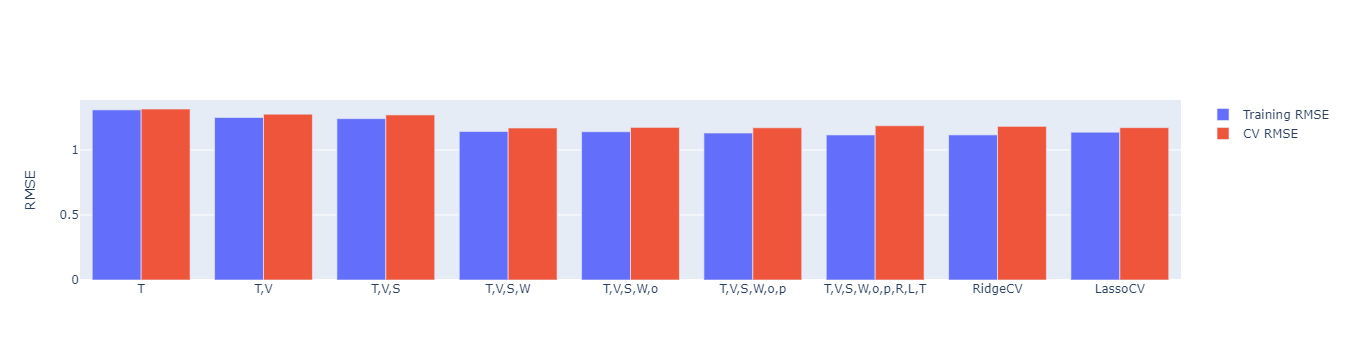

In [43]:
compare_models(models, train)

In [44]:
ct = models['LassoCV']['SelectColumns']
feature_names = (
    quantitative_features +
    list(ct.named_transformers_['retail_encoder'].get_feature_names_out())+
    list(ct.named_transformers_['law_encoder'].get_feature_names_out())+
    list(ct.named_transformers_['tax_encoder'].get_feature_names_out())
)
feature_names = np.array(feature_names)
kept = ~np.isclose(models['LassoCV']["LinearModel"].coef_, 0)
important_features = feature_names[kept]
important_features

array(['Tobacco_prev', 'Vape_Prev', 'Sale_p_c', 'Women', 'o3', 'pm'],
      dtype='<U12')

## Frequentist Regression

In [45]:
regression_df = random_forest_df.rename(columns={"strong_retail" : "Retail",
                                                  "strong_law" : "Laws",
                                                  "tax" : "Tax",
                                                  "Smoking %" : "Tobacco_prev", 
                                                  "Smokeless %" : "Vape_prev", 
                                                  "Sale per capita" : "Sale_p_c", 
                                                  "Women 18~44 %" : "Women", 
                                                  "Asthma prevalence %" : "Asthma_prev",
                                                  "ds_o3_pred" : "o3",
                                                  "ds_pm_pred" : "pm"})
regression_df.head()

,LocationDesc,YearStart,Tobacco_prev,Vape_prev,Sale_p_c,Women,Asthma_prev,o3,pm,Retail,Laws,Tax
0,Alabama,2013,21.80,6.20,64.6,21.7,8.50,52.124863,12.532084,1,0,0
1,Alabama,2014,21.40,5.90,61.7,21.5,9.50,52.124863,12.532084,1,0,0
2,Alabama,2017,21.40,6.40,58.1,21.9,10.90,52.124863,12.532084,1,0,0
3,Alabama,2018,19.60,6.45,54.7,19.2,10.45,52.124863,12.532084,1,0,0
4,Alabama,2019,20.75,6.40,53.1,22.6,9.45,52.124863,12.532084,1,0,0


In [46]:
data.exog = regression_df.drop(columns=['LocationDesc', "Asthma_prev", "YearStart", "Retail", "Laws", "Tax"])
data.endog = regression_df['Asthma_prev']

In [ ]:
freq_model = sm.GLM(data.endog, exog = sm.add_constant(data.exog, prepend=False), 
                  family=sm.families.Gaussian())
freq_res = freq_model.fit()
print(freq_res.summary())

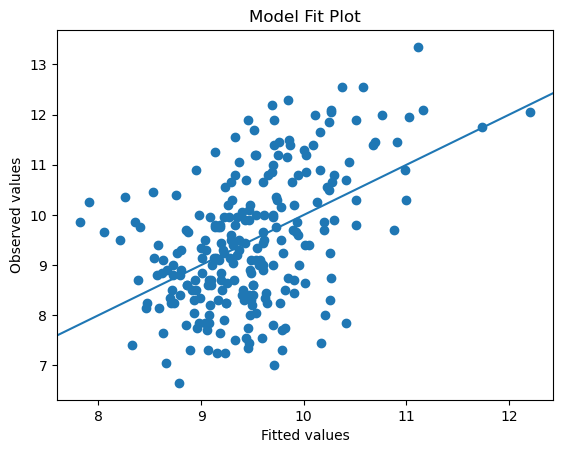

In [46]:
from statsmodels.graphics.api import abline_plot
yhat = freq_res.predict()
fig, ax = plt.subplots()
ax.scatter(freq_res.mu, data.endog)
line_fit = sm.OLS(data.endog, sm.add_constant(yhat, prepend=True)).fit()
abline_plot(model_results=line_fit, ax=ax)


ax.set_title('Model Fit Plot')
ax.set_ylabel('Observed values')
ax.set_xlabel('Fitted values');

In [47]:
np.std(data.endog)

1.3219025056889864

In [48]:
#RMSE 
np.mean((freq_res.mu - data.endog) ** 2) ** 0.5

1.153146829952904

array([[<AxesSubplot:title={'center':'Asthma_prev'}>]], dtype=object)

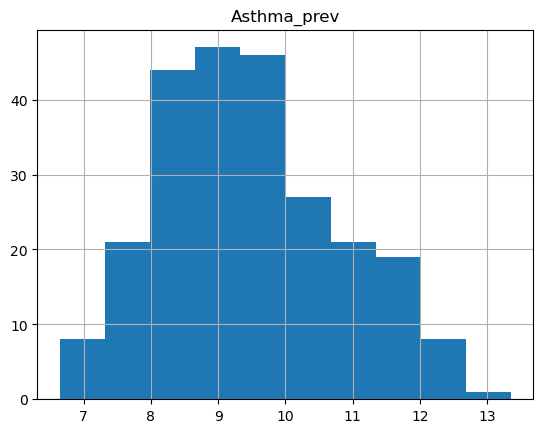

In [49]:
regression_df.hist("Asthma_prev")

In [50]:
freq_model_IG = sm.GLM(data.endog, exog = sm.add_constant(data.exog, prepend=False), 
                  family=sm.families.InverseGaussian())
freq_res_IG = freq_model_IG.fit()
print(freq_res_IG.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            Asthma_prev   No. Observations:                  242
Model:                            GLM   Df Residuals:                      235
Model Family:         InverseGaussian   Df Model:                            6
Link Function:        inverse_squared   Scale:                       0.0015742
Method:                          IRLS   Log-Likelihood:                -375.26
Date:                Thu, 08 Dec 2022   Deviance:                      0.37998
Time:                        16:12:44   Pearson chi2:                    0.370
No. Iterations:                     6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Tobacco_prev     0.0002      0.000      1.378   

/opt/conda/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning:

In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only



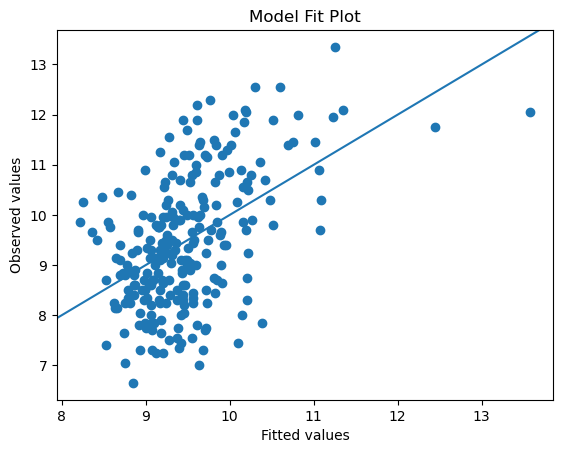

In [51]:
yhat_IG = freq_res_IG.predict()
fig, ax = plt.subplots()
ax.scatter(freq_res_IG.mu, data.endog)
line_fit = sm.OLS(data.endog, sm.add_constant(yhat, prepend=True)).fit()
abline_plot(model_results=line_fit, ax=ax)


ax.set_title('Model Fit Plot')
ax.set_ylabel('Observed values')
ax.set_xlabel('Fitted values');

In [52]:
#RMSE 
np.mean((freq_res_IG.mu - data.endog) ** 2) ** 0.5

1.1448099768001703

**Checking Uncertainty**

In [32]:
#From Lecture
def bootstrap_xy(X, y, fnc, original_estimate=None, B=1000, plot=True):

    d = X.shape[1]
    N = X.shape[0]
    w_hat = fnc(X, y)
    w_boot = np.zeros(shape=(B,d))
    for b in range(B):
        # we need to choose x-y pairs, so start by picking indices
        bootstrap_indices = np.random.choice(np.arange(N), N)
        # then, use those indices to create a bootstrap sample
        bootstrap_X = X.iloc[bootstrap_indices, :]
        bootstrap_y = y.iloc[bootstrap_indices]
        w_boot[b,:] = fnc(bootstrap_X, bootstrap_y)
    return w_boot
def lin_model(x, y): 
    model = sm.GLM(
        y, x,
        family=sm.families.Gaussian()
    )
    results = model.fit()
    params = results.params
    
    return params

# 90% confidence interval
def print_CI(mu_boot, string):
    lower = np.percentile(mu_boot, 5)
    upper = np.percentile(mu_boot, 95)
    sample_mean = np.mean(mu_boot)
    print("Confidence Interval of", string)
    print(f'Estimate of the mean: {sample_mean:0.3f}')
    print(f'90% confidence interval: ({lower:0.3f}, {upper:0.3f})')

In [33]:
w_gaussian_boot = bootstrap_xy(sm.add_constant(data.exog), data.endog, lin_model, False)
sm.add_constant(data.exog).head()

AttributeError: module 'pymc3.data' has no attribute 'exog'

In [55]:
mu_Const = []
mu_Tobacco = []
mu_Vape = []
mu_Sale = []
mu_Women = []
mu_o3 = []
mu_pm = []

for i in range(len(w_gaussian_boot)):
    mu_Const.append(w_gaussian_boot[i][0])
    mu_Tobacco.append(w_gaussian_boot[i][1])
    mu_Vape.append(w_gaussian_boot[i][2])
    mu_Sale.append(w_gaussian_boot[i][3])
    mu_Women.append(w_gaussian_boot[i][4])
    mu_o3.append(w_gaussian_boot[i][5])
    mu_pm.append(w_gaussian_boot[i][6])

In [56]:
print_CI(mu_Const, "Constant")

Confidence Interval of Constant
Estimate of the mean: 9.920
90% confidence interval: (8.847, 11.001)


In [57]:
print_CI(mu_Tobacco, "Tobacco Prevalence")

Confidence Interval of Tobacco Prevalence
Estimate of the mean: -0.093
90% confidence interval: (-0.229, 0.041)


In [58]:
print_CI(mu_Vape, "Smokeless Tobacco Prevalence")

Confidence Interval of Smokeless Tobacco Prevalence
Estimate of the mean: -0.388
90% confidence interval: (-0.490, -0.286)


In [59]:
print_CI(mu_Women, "Percentage of Female Smokers 18-44")

Confidence Interval of Percentage of Female Smokers 18-44
Estimate of the mean: 0.220
90% confidence interval: (0.141, 0.305)


In [60]:
print_CI(mu_o3, "Ozone Concentration")

Confidence Interval of Ozone Concentration
Estimate of the mean: -0.007
90% confidence interval: (-0.028, 0.014)


## Bayesian Regression

In [61]:
with pm.Model() as bayes_model:
    glm.GLM.from_formula('Asthma_prev ~ Tobacco_prev + Sale_p_c + Vape_prev + Women + o3 + pm', regression_df, family=glm.families.Normal()) 
    # PYMC3 automatically uses exponential link function and adds an intercept term
    trace_Normal = pm.sample(1000, cores=2, target_accept=0.95, init='adapt_diag')

/tmp/ipykernel_43/310218279.py:4: FutureWarning:

In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.

Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sd, pm, o3, Women, Vape_prev, Sale_p_c, Tobacco_prev, Intercept]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 39 seconds.


Got error No model on context stack. trying to find log_likelihood in translation.
/opt/conda/lib/python3.9/site-packages/arviz/data/io_pymc3_3x.py:98: FutureWarning:

Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.

Got error No model on context stack. trying to find log_likelihood in translation.


array([[<AxesSubplot:title={'center':'Intercept'}>,
        <AxesSubplot:title={'center':'Intercept'}>],
       [<AxesSubplot:title={'center':'Tobacco_prev'}>,
        <AxesSubplot:title={'center':'Tobacco_prev'}>],
       [<AxesSubplot:title={'center':'Sale_p_c'}>,
        <AxesSubplot:title={'center':'Sale_p_c'}>],
       [<AxesSubplot:title={'center':'Vape_prev'}>,
        <AxesSubplot:title={'center':'Vape_prev'}>],
       [<AxesSubplot:title={'center':'Women'}>,
        <AxesSubplot:title={'center':'Women'}>],
       [<AxesSubplot:title={'center':'o3'}>,
        <AxesSubplot:title={'center':'o3'}>],
       [<AxesSubplot:title={'center':'pm'}>,
        <AxesSubplot:title={'center':'pm'}>],
       [<AxesSubplot:title={'center':'sd'}>,
        <AxesSubplot:title={'center':'sd'}>]], dtype=object)

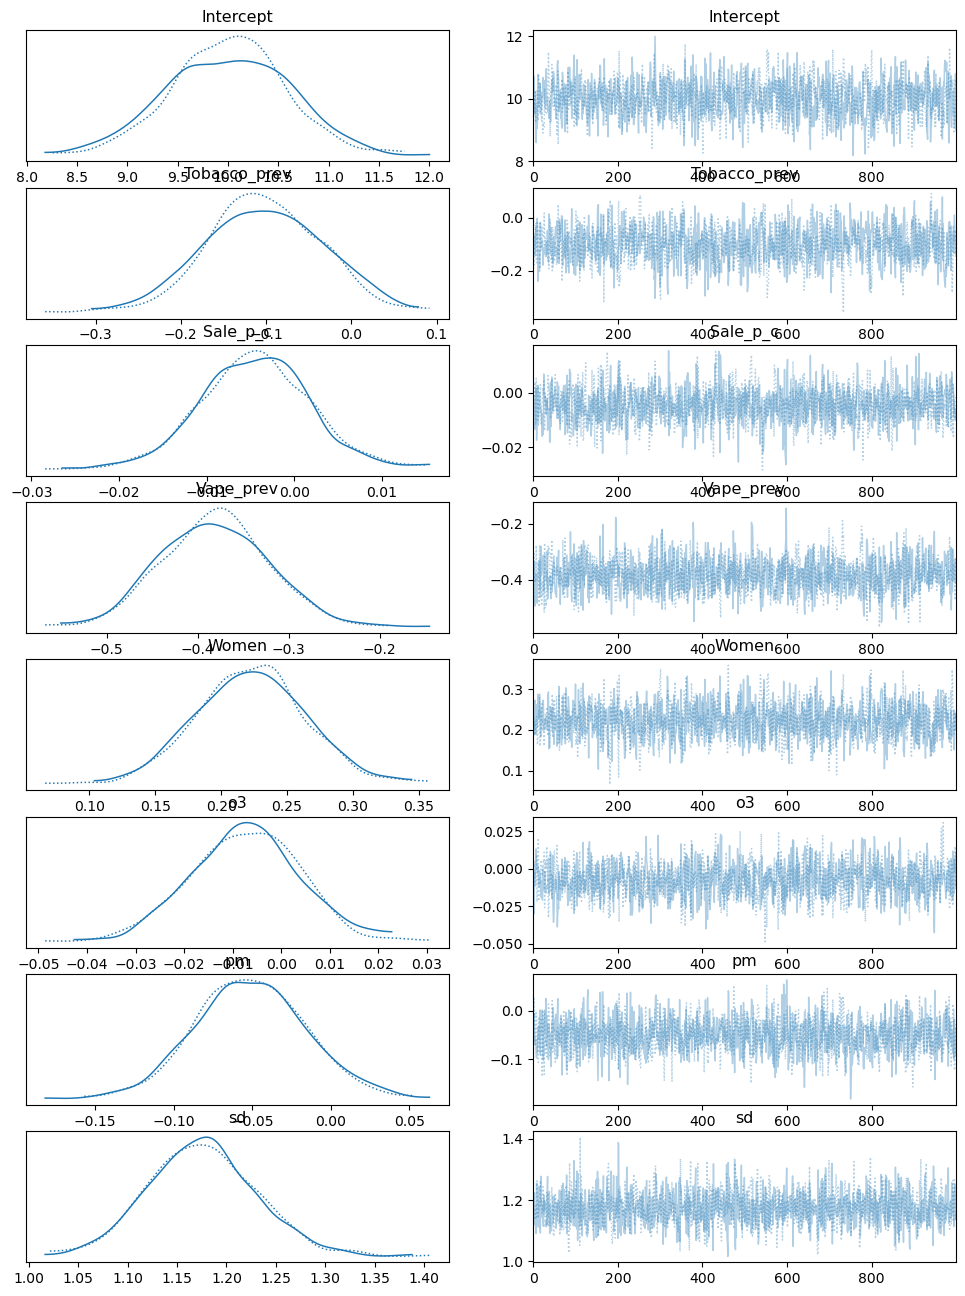

In [62]:
import arviz
arviz.plot_trace(trace_Normal)

In [63]:
az.summary(trace_Normal)

Got error No model on context stack. trying to find log_likelihood in translation.
/opt/conda/lib/python3.9/site-packages/arviz/data/io_pymc3_3x.py:98: FutureWarning:

Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.



,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,9.965,0.575,8.963,11.053,0.017,0.012,1190.0,1381.0,1.00
Sale_p_c,-0.005,0.006,-0.017,0.007,0.000,0.000,1695.0,1404.0,1.00
Tobacco_prev,-0.100,0.067,-0.223,0.025,0.002,0.001,1119.0,853.0,1.00
Vape_prev,-0.385,0.058,-0.492,-0.272,0.002,0.001,1320.0,1273.0,1.00
Women,0.223,0.043,0.148,0.310,0.001,0.001,1277.0,1010.0,1.00
o3,-0.007,0.011,-0.028,0.015,0.000,0.000,1145.0,1300.0,1.01
pm,-0.053,0.035,-0.117,0.016,0.001,0.001,1299.0,1499.0,1.00
sd,1.177,0.052,1.085,1.280,0.001,0.001,1848.0,1299.0,1.00


**Credible Interval**

In [93]:
sale_samples = trace_Normal["Vape_prev"]
sorted_sale_samples = np.sort(sale_samples)

(array([  4.,   4.,  13.,  17.,  49.,  75., 102., 139., 201., 230., 237.,
        260., 220., 160., 103.,  79.,  61.,  27.,  14.,   5.]),
 array([-0.58201168, -0.56340059, -0.54478949, -0.5261784 , -0.50756731,
        -0.48895622, -0.47034513, -0.45173404, -0.43312295, -0.41451186,
        -0.39590077, -0.37728968, -0.35867859, -0.3400675 , -0.3214564 ,
        -0.30284531, -0.28423422, -0.26562313, -0.24701204, -0.22840095,
        -0.20978986]),
 <BarContainer object of 20 artists>)

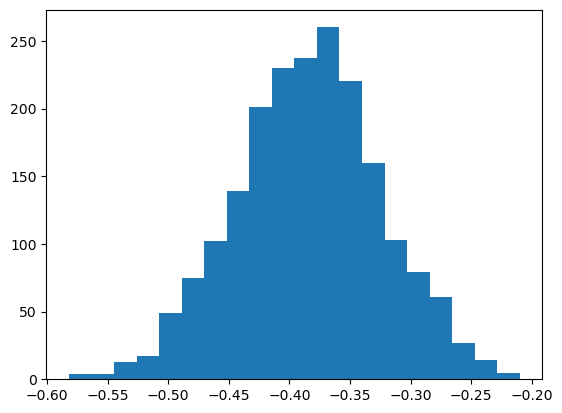

In [94]:
plt.hist(sale_samples, bins=20)

In [108]:
print("Credible Interval of Smokeless Tobacco Prevalence Coefficient")
print(f'Estimate of the mean: {np.mean(sale_samples):0.3f}')
print(f'95% Credible interval: ({sale_samples[50]:0.3f}, {sale_samples[1950]:0.3f})')

Credible Interval of Smokeless Tobacco Prevalence Coefficient
Estimate of the mean: -0.384
95% Credible interval: (-0.427, -0.324)


**Posterior Predictive Check**

In [107]:
with pm.Model() as bayes_model_simple:
    glm.GLM.from_formula('Asthma_prev ~ Women', regression_df, family=glm.families.Normal()) 
    # PYMC3 automatically uses exponential link function and adds an intercept term
    trace_Normal = pm.sample(1000, cores=2, target_accept=0.95, init='adapt_diag')

/tmp/ipykernel_41/3027624124.py:4: FutureWarning:

In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.

Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sd, Women, Intercept]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 5 seconds.


In [109]:
with bayes_model_simple:
    gaussian_ppc = pm.sample_posterior_predictive(
        trace_Normal, var_names=["Intercept", "Women",  "y"]
    )

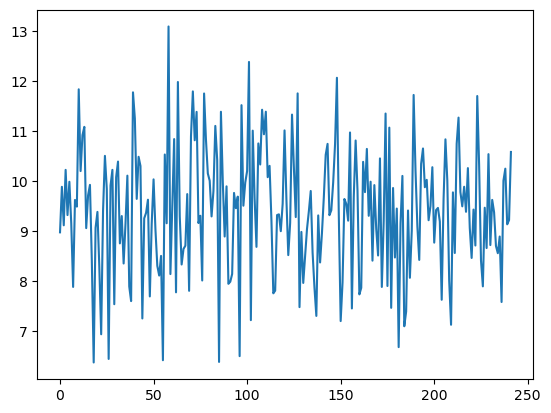

In [110]:
plt.plot(gaussian_ppc['y'][47, :])

In [111]:
def compute_avg_prediction(ppc):
    linear_part = np.outer(ppc["Women"], regression_df.Sale_p_c.values) + ppc["Intercept"][:,np.newaxis]
    return linear_part

In [112]:
y_hat_gaussian = compute_avg_prediction(gaussian_ppc)

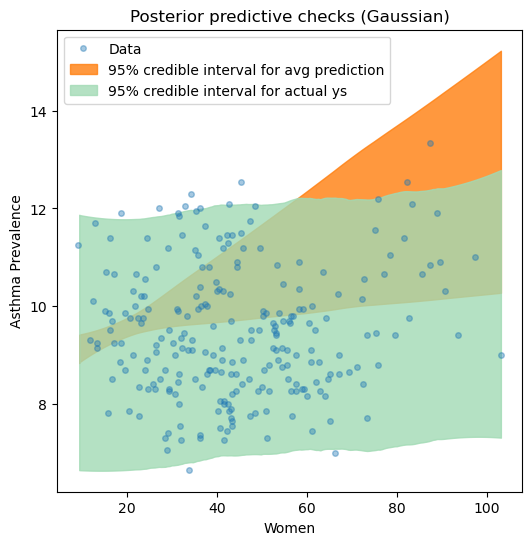

In [114]:
_, ax = plt.subplots(figsize = (6,6))

ax.plot(regression_df.Sale_p_c, regression_df.Asthma_prev, "o", ms=4, alpha=0.4, label="Data")
az.plot_hdi(
    regression_df.Sale_p_c,
    y_hat_gaussian,
    ax=ax,
    hdi_prob=0.95,
    fill_kwargs={"alpha": 0.8, "label": "95% credible interval for avg prediction"},
)
az.plot_hdi(
    regression_df.Sale_p_c,
    gaussian_ppc["y"],
    ax=ax,
    hdi_prob=0.95,
    fill_kwargs={"alpha": 0.8, "color": "#a1dab4", "label": "95% credible interval for actual ys"},
)

ax.set_xlabel("Women")
ax.set_ylabel("Asthma Prevalence")
ax.set_title("Posterior predictive checks (Gaussian)")
ax.legend(fontsize=10);

## Casual Inference

In [25]:
Tax1 = Tax.drop(columns = "Data Range")

2019 excise tax amount

In [26]:
Tax1.loc[15,['ProvisionValue']] = 1.98
Tax1.loc[23,['ProvisionValue']] = 2.00
Tax1.loc[34,['ProvisionValue']] = 1.66
Tax1.loc[41,['ProvisionValue']] = 1.33
Tax1.loc[53,['ProvisionValue']] = 0.3

In [27]:
new = merge_df(Tax1, Final_merged)

In [28]:
final = new.drop(new.index[[11, 12, 40, 48]]).reset_index(drop = True)
fianl = final.dropna()
final['Sale per capita'].corr(final['ProvisionValue'])

-0.6299492308277349

In [29]:
final1 = final[["ProvisionValue", "Smoking %", "Sale per capita", "Asthma prevalence %"]]

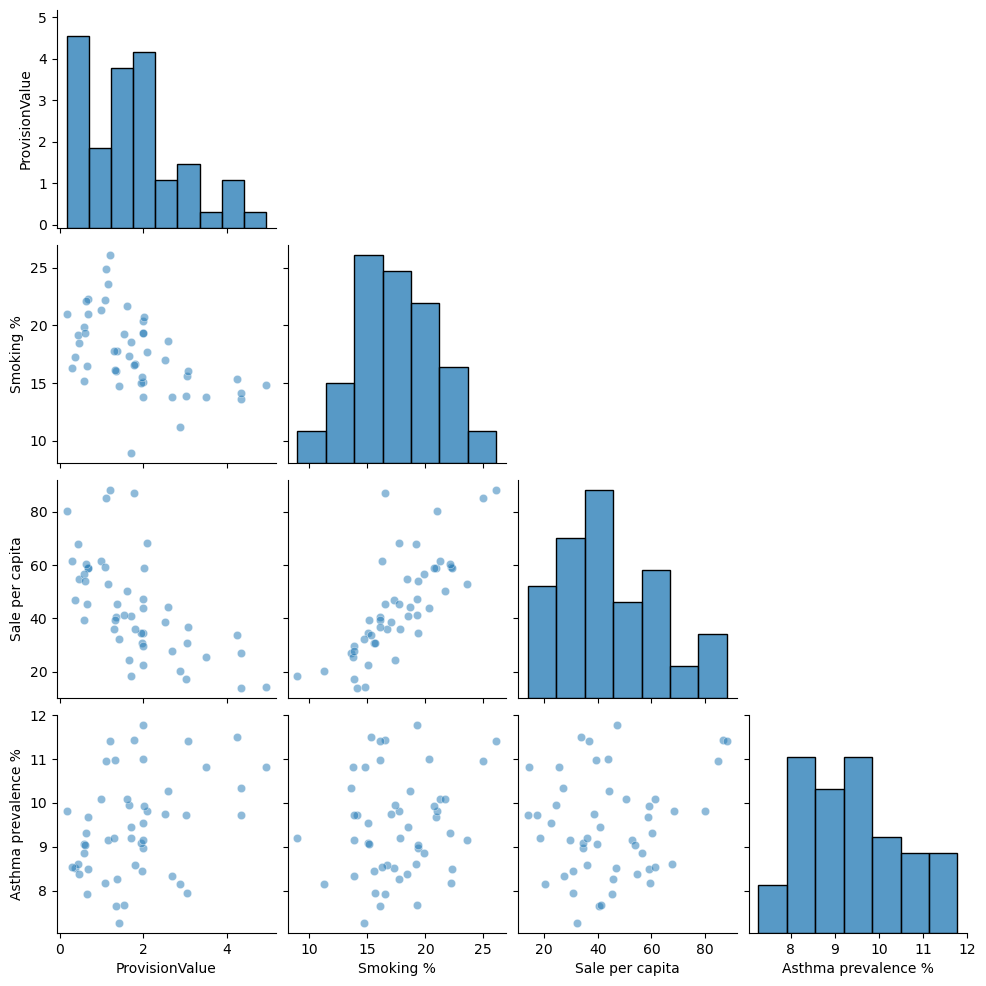

In [30]:
#From lab 7
fig = sns.pairplot(final1,  plot_kws=dict(marker="o", alpha = 0.5))
for i, j in zip(*np.triu_indices_from(fig.axes, 1)):
    fig.axes[i, j].set_visible(False)
plt.show()

W = Provision Value (Excise Tax)
X = Smoking %
Z = Sale per capita
Y = Asthma Prevalence

In [43]:
#from lab 7
def fit_OLS_model(df, target_variable, explanatory_variables, intercept = False):
    target = df[target_variable]
    inputs = df[explanatory_variables]
    if intercept:
        inputs = sm.add_constant(inputs)
    
    fitted_model = sm.OLS(target, inputs).fit()
    return(fitted_model)

In [44]:
betas_model = fit_OLS_model(final1, 'Asthma prevalence %', ['Sale per capita', 'Smoking %'])
betas = betas_model.params
print("The estimated causal effect on Asthma prevalence of an additional sale of tobacco per capita is {:.2f}".format(betas[0]))
print("The estimated causal effect on Asthma prevalence of an additional Smoking % is {:.2f}".format(betas[1]))

The estimated causal effect on Asthma prevalence of an additional sale of tobacco per capita is -0.05
The estimated causal effect on Asthma prevalence of an additional Smoking % is 0.64


**Step 1**

In [45]:
# Fit OLS parameters to predict Z from W
gamma1_model = fit_OLS_model(final1, 'Sale per capita', 'ProvisionValue', True)
print(gamma1_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Sale per capita   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     31.58
Date:                Fri, 09 Dec 2022   Prob (F-statistic):           9.50e-07
Time:                        16:43:14   Log-Likelihood:                -203.94
No. Observations:                  50   AIC:                             411.9
Df Residuals:                      48   BIC:                             415.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             62.7574      3.859     16.

In [46]:
#from lab 7
# Compute predictions for sale per capita
intercept_OLS = gamma1_model.params[0]
gamma1_OLS = gamma1_model.params[1]
Z_hat = intercept_OLS + gamma1_OLS*final1['ProvisionValue']

# Add the predictions to the final1 dataframe
final1['Predicted Sale per capita'] = Z_hat
final1.head()

,ProvisionValue,Smoking %,Sale per capita,Asthma prevalence %,Predicted Sale per capita
0,0.675,20.95625,58.716667,9.68125,55.837665
1,2.000,19.36875,34.366667,8.97500,42.254456
2,2.000,15.08750,22.583333,9.54375,42.254456
3,1.150,23.61250,52.716667,9.16250,50.968213
4,2.870,11.22500,20.250000,8.16250,33.335670


**Step 2**

In [47]:
# Fit OLS parameters to predict Y from the predicted Z_hat.
beta1_model = fit_OLS_model(final1, 'Asthma prevalence %', 'Predicted Sale per capita', True)
print(beta1_model.summary())

                             OLS Regression Results                            
Dep. Variable:     Asthma prevalence %   R-squared:                       0.141
Model:                             OLS   Adj. R-squared:                  0.123
Method:                  Least Squares   F-statistic:                     7.853
Date:                 Fri, 09 Dec 2022   Prob (F-statistic):            0.00730
Time:                         16:43:15   Log-Likelihood:                -73.495
No. Observations:                   50   AIC:                             151.0
Df Residuals:                       48   BIC:                             154.8
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const       

/opt/conda/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning:

In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only



In [48]:
beta_naive_model = fit_OLS_model(final1, 'Asthma prevalence %', 'Sale per capita', True)
print("The Naive OLS estimate of beta_1 is {:.2f}, while the true beta_1 is {}".format(beta_naive_model.params[1], -0.05))

The Naive OLS estimate of beta_1 is 0.01, while the true beta_1 is -0.05


/opt/conda/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning:

In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only



In [49]:
print("The 2SLS estimate of beta_1 is {:.3f}, while the true value is {}".format(beta1_model.params[1], -0.05))

The 2SLS estimate of beta_1 is -0.037, while the true value is -0.05


**Quantifiying Uncertainty**

In [81]:
def beta_model(x, y): 
    model = sm.OLS(y, x).fit()
    params = model.params
    return params


In [82]:
ci = bootstrap_xy(sm.add_constant(final1["Predicted Sale per capita"]), final1["Asthma prevalence %"], beta_model, False)

In [83]:
mu_constant = []
mu_spc = []

for i in range(len(ci)):
    mu_constant.append(ci[i][0])
    mu_spc.append(ci[i][1])

In [84]:
print_CI(mu_spc, "Sales per Capita")

Confidence Interval of Sales per Capita
Estimate of the mean: -0.036
90% confidence interval: (-0.053, -0.017)


Error in atexit._run_exitfuncs:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.9/site-packages/popularity_contest/reporter.py", line 105, in report_popularity
    libraries = get_used_libraries(initial_modules, current_modules)
  File "/opt/conda/lib/python3.9/site-packages/popularity_contest/reporter.py", line 74, in get_used_libraries
    all_packages = get_all_packages()
  File "/opt/conda/lib/python3.9/site-packages/popularity_contest/reporter.py", line 51, in get_all_packages
    for f in dist.files:
TypeError: 'NoneType' object is not iterable
